In [1]:
import psycopg2
import pandas as pd
import networkx as nx
import base58
import matplotlib.pyplot as plt
import re
import math
import matplotlib.dates as mdates
import networkx as nx
from collections import defaultdict
from networkx.algorithms.approximation.clique import large_clique_size
from itertools import combinations
import numpy as np
from networkx.algorithms.coloring import greedy_color
import random

In [2]:
# Connect to PostgreSQL and fetch data
conn = psycopg2.connect(
    dbname="sui_indexer",
    user="postgres",
    password="56904628",
    host="172.26.112.1",
    port=5432
)
conn.autocommit = True
cur = conn.cursor()

Count transactions

In [42]:
cur.execute("""
SELECT
    (SELECT COUNT(*) FROM transactions) AS total_tx,
    (SELECT SUM(user_tx_count) FROM checkpoints) AS user_tx,
    (SELECT SUM(system_tx_count) FROM checkpoints) AS system_tx,
    (SELECT COUNT(*) FROM checkpoints) AS total_checkpoints;
""")

total_tx, user_tx, system_tx, total_checkpoints = cur.fetchone()

print("Total transactions:", total_tx)
print("Total user tx:", user_tx)
print("Total system tx:", system_tx)
print("Total checkpoints:", total_checkpoints)


Total transactions: 1879897
Total user tx: 1672398
Total system tx: 210045
Total checkpoints: 70889


In [43]:
cur.execute("SELECT COUNT(*) FROM object_changes;")
total_object_changes = cur.fetchone()[0]
print("Total object changes:", total_object_changes)

Total object changes: 8822101


In [167]:
cur.execute("""SELECT digest FROM checkpoints WHERE sequence_number = '22530055';""")
hex_str = cur.fetchone()[0].hex()
digest_bytes = bytes.fromhex(hex_str)
base58_str = base58.b58encode(digest_bytes).decode()
print(base58_str)

GFi72GQ31az5cQFqanEohGVGijkKWHAfwQnpBu6oXfm8


In [43]:
cur.execute("""SELECT sequence_number, timestamp
FROM checkpoints
ORDER BY sequence_number DESC
LIMIT 1;""")

sequence_number, timestamp = cur.fetchone()

print("Latest checkpoint sequence number:", sequence_number)
print("Latest checkpoint timestamp:", timestamp)


Latest checkpoint sequence number: 218587485
Latest checkpoint timestamp: 2025-12-02 13:44:38.398000+00:00


In [42]:
cur.execute("""SELECT * FROM watermarks WHERE pipeline = 'checkpoint_handler';""")
temp = cur.fetchall()
temp

[('checkpoint_handler',
  964,
  218587593,
  4489684045,
  1764683103421,
  0,
  datetime.datetime(1970, 1, 1, 0, 0),
  0)]

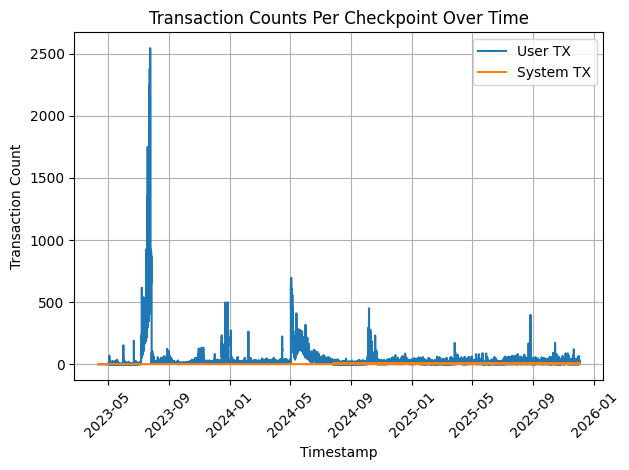

In [44]:
cur.execute("SELECT timestamp, user_tx_count, system_tx_count FROM checkpoints ORDER BY timestamp;")

rows = cur.fetchall()

df = pd.DataFrame(rows, columns=[
    "timestamp",
    "user_tx_count",
    "system_tx_count"
])

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

plt.figure()
plt.plot(df["timestamp"], df["user_tx_count"], label="User TX")
plt.plot(df["timestamp"], df["system_tx_count"], label="System TX")

plt.xlabel("Timestamp")
plt.ylabel("Transaction Count")
plt.title("Transaction Counts Per Checkpoint Over Time")
plt.legend()
plt.grid(True)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())  
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

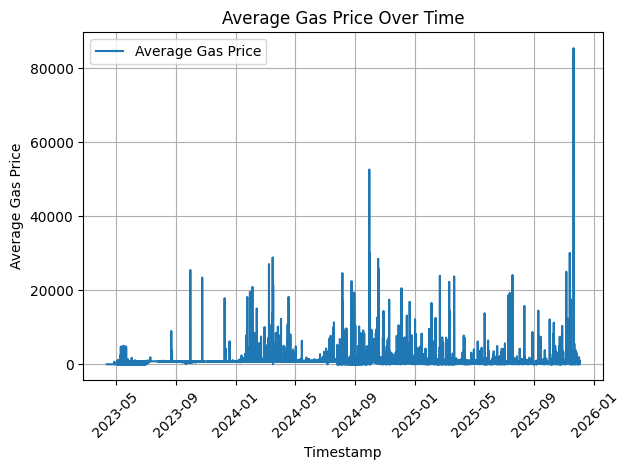

In [45]:
cur.execute("""
    SELECT 
        c.timestamp,
        AVG(t.gas_price) AS avg_gas_price
    FROM transactions t
    JOIN checkpoints c
        ON t.checkpoint_sequence = c.sequence_number
    GROUP BY c.timestamp
    ORDER BY c.timestamp;
""")

rows = cur.fetchall()

df = pd.DataFrame(rows, columns=["timestamp", "avg_gas_price"])

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

plt.figure()
plt.plot(df["timestamp"], df["avg_gas_price"], label="Average Gas Price")

plt.xlabel("Timestamp")
plt.ylabel("Average Gas Price")
plt.title("Average Gas Price Over Time")
plt.legend()
plt.grid(True)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())  
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [46]:
def shorten_error(err):

    # Force bytes → str safely
    if isinstance(err, bytes):
        err = err.decode("utf-8", errors="replace")
    else:
        err = str(err)

    # Case 1: If Abort Code actually exists (clean numeric label)
    match = re.search(r"Abort Code[:\s]+(\d+)", err)
    if match:
        code = match.group(1)
        return f"Move Abort Code {code}"

    # Case 2: Your CURRENT format: "Move Runtime Abort, Location: <hex>..."
    if "Move Runtime Abort" in err and "Location:" in err:
        # Extract first 8 hex chars after Location:
        hex_match = re.search(r"Location:\s*([0-9a-fA-F]{6,})", err)
        if hex_match:
            short_hex = hex_match.group(1)[:8]
            return f"Move {short_hex}"

        return "Move Runtime Abort"

    if "Insufficient Gas" in err:
        return "Insufficient Gas"

    if "Insufficient coin balance" in err:
        return "Insufficient Balance"

    return err[:30] + "..."


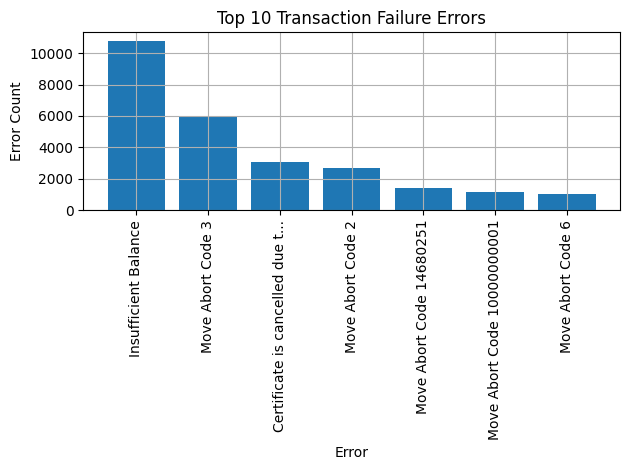

In [47]:
cur.execute("SELECT error FROM transactions WHERE status = 'failure';")

cur.execute("""
    SELECT error, COUNT(*) 
    FROM transactions
    WHERE status = 'failure'
      AND error IS NOT NULL
    GROUP BY error
    ORDER BY COUNT(*) DESC
    LIMIT 10;
""")

rows = cur.fetchall()

decoded_errors = []
counts = []

for error_bytes, count in rows:
    hex_str = error_bytes.hex()
    error_string = bytes.fromhex(hex_str)

    decoded_errors.append(error_string)
    counts.append(count)

df = pd.DataFrame({
    "error": decoded_errors,
    "count": counts
})

df["short_error"] = df["error"].apply(shorten_error)

plt.figure()
plt.bar(df["short_error"], df["count"])

plt.xlabel("Error")
plt.ylabel("Error Count")
plt.title("Top 10 Transaction Failure Errors")
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True)
plt.show()

Concurrent write operations

In [48]:
cur.execute("""SELECT
    oc1.transaction_digest AS tx1,
    oc2.transaction_digest AS tx2,
    oc1.address,
    c.sequence_number AS checkpoint
FROM object_changes oc1
JOIN object_changes oc2
    ON oc1.address = oc2.address
    AND oc1.transaction_digest < oc2.transaction_digest
JOIN transactions t1
    ON oc1.transaction_digest = t1.transaction_digest
JOIN transactions t2
    ON oc2.transaction_digest = t2.transaction_digest
JOIN checkpoints c
    ON t1.checkpoint_sequence = c.sequence_number
    AND t2.checkpoint_sequence = c.sequence_number
WHERE
    -- BOTH are write operations
    oc1.change_type IS NOT NULL
    AND oc2.change_type IS NOT NULL;""")

rows = cur.fetchall()
len(rows)

7205998

Create concurrent WRITE graphs

In [49]:
# Group edges by checkpoint
graphs = defaultdict(nx.Graph)

for tx1, tx2, object_address, checkpoint in rows:
    G = graphs[checkpoint]
    G.add_edge(tx1.hex(), tx2.hex(), object=object_address.hex())

# graphs[checkpoint] = NetworkX conflict graph for that checkpoint
print(f"Built {len(graphs)} checkpoint graphs")

Built 62826 checkpoint graphs


Visualize one graph

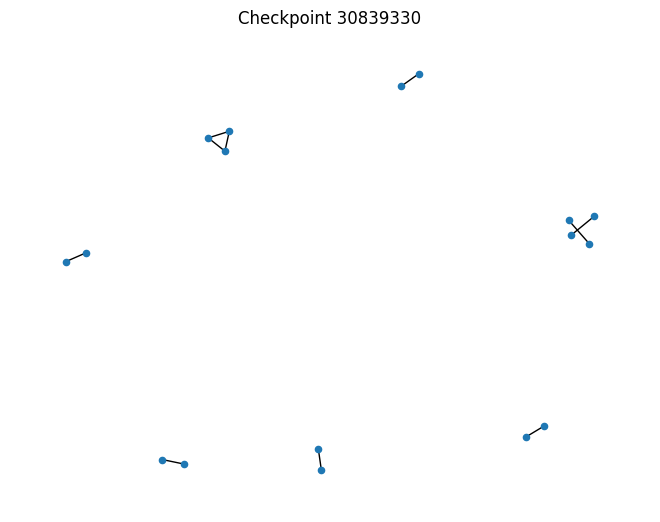

In [116]:
cp = list(graphs.keys())[10]
G = graphs[cp]

plt.figure()
nx.draw(G, node_size=20, with_labels=False)
plt.title(f"Checkpoint {cp}")
plt.show()

Visualize the graph with more concurrent writes

Random checkpoint with > 150 transactions: 33085080
Number of transactions (nodes): 155
Number of concurrent write edges: 91


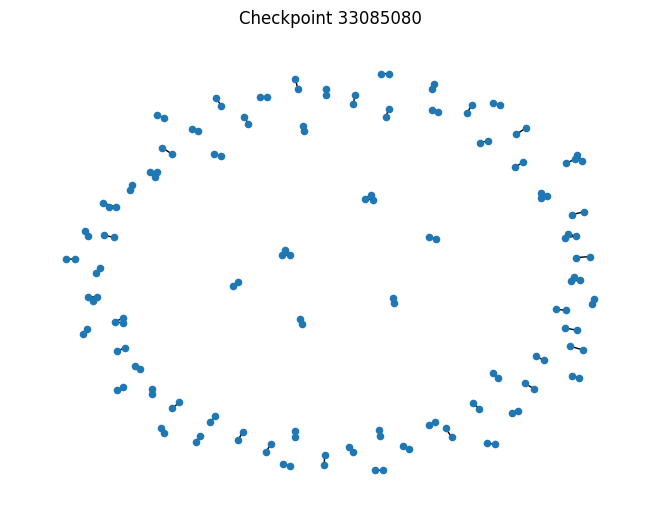

In [103]:
# Set your minimum size threshold here
N = 150

# Find all checkpoints whose graph has more than N nodes with high density
eligible_cps = [
    cp for cp, G in graphs.items()
    if G.number_of_nodes() > N #and G.number_of_edges() > 5 * N
]

if not eligible_cps:
    print(f"No checkpoint found with more than {N} nodes.")
else:
    # Randomly select one
    cp_rand = random.choice(eligible_cps)
    G_rand = graphs[cp_rand]

    print(f"Random checkpoint with > {N} transactions: {cp_rand}")
    print(f"Number of transactions (nodes): {G_rand.number_of_nodes()}")
    print(f"Number of concurrent write edges: {G_rand.number_of_edges()}")

    plt.figure()
    nx.draw(G_rand, node_size=20, with_labels=False)
    plt.title(f"Checkpoint {cp_rand}")
    plt.show()

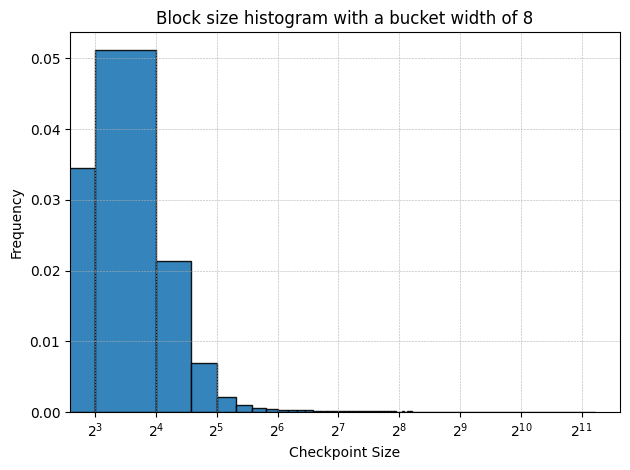

In [52]:
cur.execute("""
    SELECT checkpoint_sequence, COUNT(*) AS size
    FROM transactions
    GROUP BY checkpoint_sequence
    ORDER BY checkpoint_sequence;
""")
rows = cur.fetchall()

df = pd.DataFrame(rows, columns=["checkpoint", "size"])
sizes = df["size"].values

# Create bucket width of 8
max_size = sizes.max()
bin_edges = np.arange(0, max_size + 8, 8)

# Plot histogram with those bins
counts, bins, patches = plt.hist(
    sizes,
    bins=bin_edges,
    density=True,
    edgecolor="black",
    alpha=0.9
)

# Log2 x-axis (paper-style)
plt.xscale("log", base=2)
plt.xlabel("Checkpoint Size")
plt.ylabel("Frequency")
plt.title("Block size histogram with a bucket width of 8")

plt.grid(True, which="both", linestyle="--", linewidth=0.4)
plt.tight_layout()
plt.show()


In [53]:
# Approximate pure value transfer transactions
cur.execute("""SELECT checkpoint_sequence, transaction_digest
FROM transactions
WHERE kind = 'ProgrammableTransaction'
  AND command_move_call = 0
  AND command_publish = 0
  AND command_upgrade = 0
  AND command_make_move_vec = 0
  AND (
        command_transfer_objects > 0 OR
        command_split_coins > 0 OR
        command_merge_coins > 0
      );""")
rows = cur.fetchall()

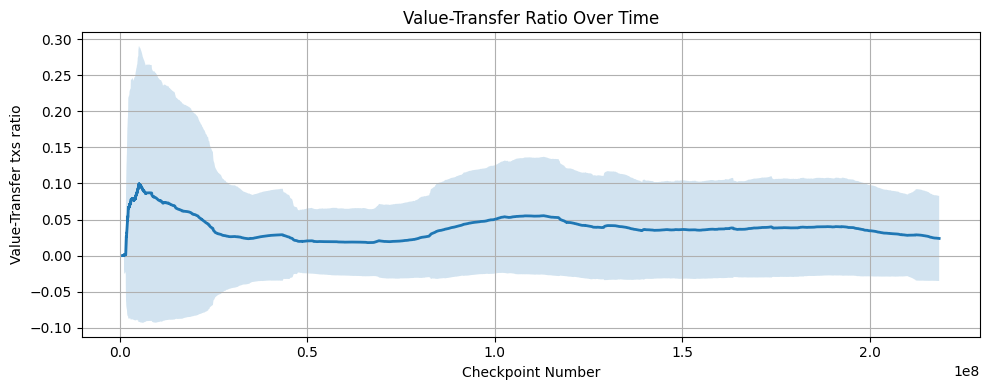

In [54]:

# Load ALL transactions for computing total per checkpoint
cur.execute("SELECT checkpoint_sequence, transaction_digest FROM transactions;")
all_tx = cur.fetchall()

df_all = pd.DataFrame(all_tx, columns=["checkpoint", "digest"])

# Load pure value transfer transactions (you already computed rows)
df_pure = pd.DataFrame(rows, columns=[desc.name for desc in cur.description])

# Keep only checkpoint + digest
df_pure = df_pure[["checkpoint_sequence", "transaction_digest"]]
df_pure.rename(columns={"checkpoint_sequence": "checkpoint"}, inplace=True)

# Count totals and pure-transfer per checkpoint
total_per_cp = df_all.groupby("checkpoint").size()
pure_per_cp = df_pure.groupby("checkpoint").size()

# Align indexes
ratio = (pure_per_cp / total_per_cp).fillna(0)
ratio.name = "pure_ratio"

ratio_series = pd.Series(ratio.values, index=ratio.index)

window = 10000  # adjust based on your checkpoint count scale

smooth = ratio_series.rolling(window, min_periods=1000).mean()
std = ratio_series.rolling(window, min_periods=1000).std()

plt.figure(figsize=(10, 4))

# Shaded region (mean ± std)
plt.fill_between(
    ratio_series.index,
    smooth - std,
    smooth + std,
    alpha=0.2
)

# Smoothed mean line
plt.plot(
    ratio_series.index,
    smooth,
    linewidth=2
)

plt.xlabel("Checkpoint Number")
plt.ylabel("Value-Transfer txs ratio")
plt.title("Value-Transfer Ratio Over Time")
plt.grid(True)
plt.tight_layout()
plt.show()


Graph density

In [55]:
density = {cp: nx.density(G) for cp, G in graphs.items()}

# Convert density dict → DataFrame
df_density = pd.DataFrame(list(density.items()), columns=["checkpoint", "density"])


C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\1040350010.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = group.groupby("density_bin")["pure_ratio"].agg(
C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\1040350010.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = group.groupby("density_bin")["density"].mean()


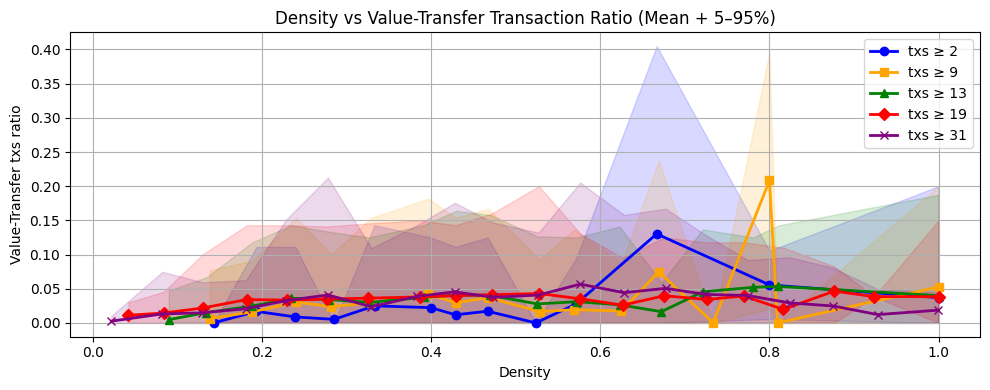

In [56]:
# Merge with ratio
df_ratio = ratio.reset_index()
df_ratio = df_ratio.rename(columns={"index": "checkpoint"})

df_merge = pd.merge(df_density, df_ratio, on="checkpoint", how="inner")

# Add checkpoint size
df_sizes = total_per_cp.reset_index()
df_sizes.columns = ["checkpoint", "size"]
df_merge = df_merge.merge(df_sizes, on="checkpoint", how="inner")

# Compute dynamic quantile thresholds
q25, q50, q75, q90 = np.percentile(df_merge["size"], [25, 50, 75, 90])

ranges = [
    (0, q25),
    (q25, q50),
    (q50, q75),
    (q75, q90),
    (q90, np.inf)
]

mins = [
    df_merge["size"].min(),
    q25,
    q50,
    q75,
    q90
]

labels = [f"txs ≥ {m:.0f}" for m in mins]

colors = ["blue", "orange", "green", "red", "purple"]
markers = ["o", "s", "^", "D", "x"]

# Bin density into categories
df_merge["density_bin"] = pd.cut(df_merge["density"], bins=20)

plt.figure(figsize=(10, 4))

# Plot each quantile-range group
for i, (low, high) in enumerate(ranges):

    group = df_merge[(df_merge["size"] > low) & (df_merge["size"] <= high)]
    if group.empty:
        continue

    # compute statistics
    stats = group.groupby("density_bin")["pure_ratio"].agg(
        mean="mean",
        p5=lambda x: np.percentile(x, 5) if len(x) > 0 else np.nan,
        p95=lambda x: np.percentile(x, 95) if len(x) > 0 else np.nan,
    )

    # density bin centers
    centers = group.groupby("density_bin")["density"].mean()

    # align and drop NaNs
    stats = stats.reindex(centers.index)
    mask = ~stats["mean"].isna()
    stats = stats[mask]
    centers = centers[mask]

    # 5–95% band
    plt.fill_between(
        centers,
        stats["p5"],
        stats["p95"],
        alpha=0.15,
        color=colors[i]
    )

    # median line
    plt.plot(
        centers,
        stats["mean"],
        marker=markers[i],
        color=colors[i],
        linewidth=2,
        label=labels[i]
    )

plt.xlabel("Density")
plt.ylabel("Value-Transfer txs ratio")
plt.title("Density vs Value-Transfer Transaction Ratio (Mean + 5–95%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Diameter

C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\1341974211.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = group.groupby("density_bin")["diameter"].agg(
C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\1341974211.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = group.groupby("density_bin")["density"].mean()


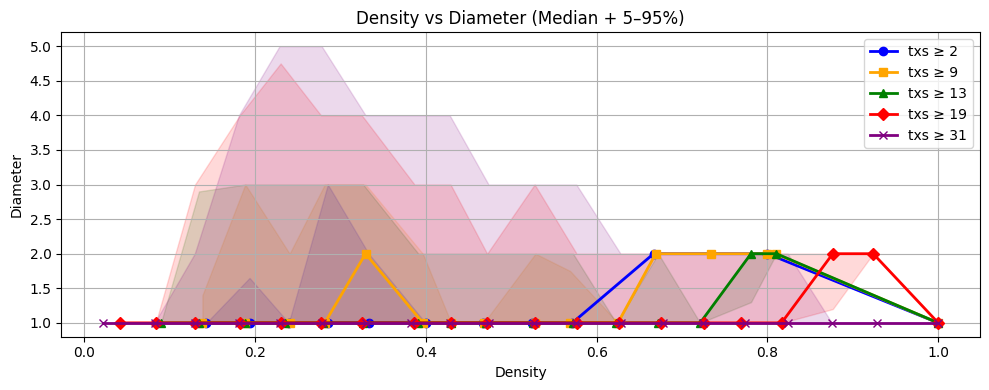

In [57]:
diameter = {}

for cp, G in graphs.items():
    # Skip empty or trivial graphs
    if G.number_of_nodes() < 2:
        diameter[cp] = 0
        continue

    # DIAMETER (safe version: per connected component)
    if nx.is_connected(G):
        diameter[cp] = nx.diameter(G)
    else:
        diameter[cp] = max(
            nx.diameter(G.subgraph(c))
            for c in nx.connected_components(G)
            if len(c) > 1
        )

df_diameter = pd.DataFrame(list(diameter.items()), columns=["checkpoint", "diameter"])

# Merge: density + diameter + block size
df_merge = (
    df_density
    .merge(df_diameter, on="checkpoint", how="inner")
    .merge(df_sizes.rename(columns={"size": "block_size"}), on="checkpoint", how="inner")
)

# Quantile thresholds for block size
q25, q50, q75, q90 = np.percentile(df_merge["block_size"], [25, 50, 75, 90])
ranges = [
    (0, q25),
    (q25, q50),
    (q50, q75),
    (q75, q90),
    (q90, np.inf),
]

mins = [
    df_merge["block_size"].min(),
    q25,
    q50,
    q75,
    q90
]

labels = [f"txs ≥ {m:.0f}" for m in mins]

colors = ["blue", "orange", "green", "red", "purple"]
markers = ["o", "s", "^", "D", "x"]

# Density bins
df_merge["density_bin"] = pd.cut(df_merge["density"], bins=20)

plt.figure(figsize=(10, 4))

# Plot each quantile range
for i, (low, high) in enumerate(ranges):

    group = df_merge[(df_merge["block_size"] > low) & (df_merge["block_size"] <= high)]
    if group.empty:
        continue

    # Aggregate statistics: median + 5–95% band
    stats = group.groupby("density_bin")["diameter"].agg(
        median="median",
        p5=lambda x: np.percentile(x, 5) if len(x) else np.nan,
        p95=lambda x: np.percentile(x, 95) if len(x) else np.nan,
    )

    # Density-bin centers (x-values)
    centers = group.groupby("density_bin")["density"].mean()

    # Align + drop NaNs
    stats = stats.reindex(centers.index)
    mask = ~stats["median"].isna()
    stats = stats[mask]
    centers = centers[mask]

    # 5–95% band
    plt.fill_between(
        centers,
        stats["p5"],
        stats["p95"],
        alpha=0.15,
        color=colors[i],
    )

    # Median curve
    plt.plot(
        centers,
        stats["median"],
        marker=markers[i],
        color=colors[i],
        linewidth=2,
        label=labels[i],
    )

plt.xlabel("Density")
plt.ylabel("Diameter")
plt.title("Density vs Diameter (Median + 5–95%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# diameter 1 - complete graph (clique), all transactions in the graph conflict with each other
# diameter 2 - star, transactions in the graph have concurrent access with a central transaction
# result shows diameter mostly 1 with occasion 2, suggesting most concurrent writes are cliques

Degree Distribution (Detect Hub Objects)

In [58]:
max_degree = {}
mean_degree = {}

for cp, G in graphs.items():
    if G.number_of_nodes() == 0:
        max_degree[cp] = 0
        mean_degree[cp] = 0
        continue

    deg_values = [d for _, d in G.degree()]

    max_degree[cp] = max(deg_values)
    mean_degree[cp] = np.mean(deg_values)

df_maxdeg = pd.DataFrame(list(max_degree.items()), columns=["checkpoint", "max_degree"])
df_meandeg = pd.DataFrame(list(mean_degree.items()), columns=["checkpoint", "mean_degree"])

# Merge with density + block size
df_merge_deg = (
    df_density
    .merge(df_maxdeg, on="checkpoint", how="inner")
    .merge(df_meandeg, on="checkpoint", how="inner")
    .merge(df_sizes.rename(columns={"size": "block_size"}), on="checkpoint", how="inner")
)

# quantile ranges
q25, q50, q75, q90 = np.percentile(df_merge_deg["block_size"], [25, 50, 75, 90])

ranges = [
    (0, q25),
    (q25, q50),
    (q50, q75),
    (q75, q90),
    (q90, np.inf),
]

mins = [
    df_merge["block_size"].min(),
    q25,
    q50,
    q75,
    q90
]

labels = [f"txs ≥ {m:.0f}" for m in mins]

colors = ["blue", "orange", "green", "red", "purple"]
markers = ["o", "s", "^", "D", "x"]

df_merge_deg["density_bin"] = pd.cut(df_merge_deg["density"], bins=20)

C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\2730809240.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = group.groupby("density_bin")["max_degree"].agg(
C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\2730809240.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = group.groupby("density_bin")["density"].mean()


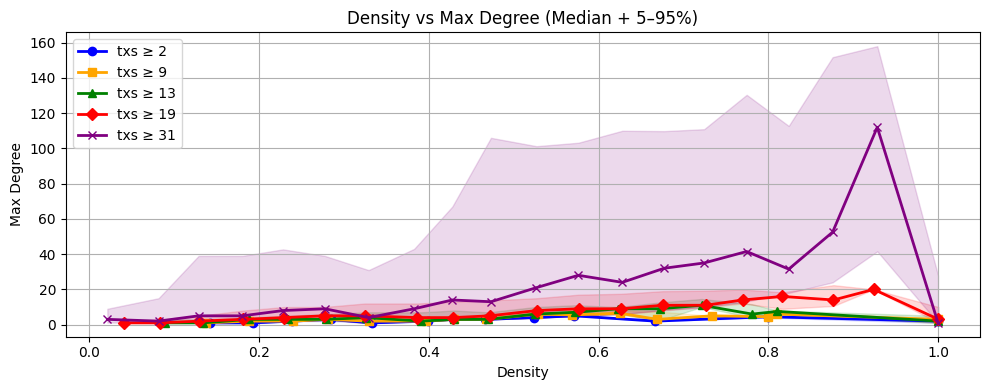

In [59]:
# max degree vs density
plt.figure(figsize=(10, 4))

for i, (low, high) in enumerate(ranges):

    group = df_merge_deg[
        (df_merge_deg["block_size"] > low) &
        (df_merge_deg["block_size"] <= high)
    ]
    if group.empty:
        continue

    stats = group.groupby("density_bin")["max_degree"].agg(
        median="median",
        p5=lambda x: np.percentile(x, 5) if len(x) else np.nan,
        p95=lambda x: np.percentile(x, 95) if len(x) else np.nan,
    )

    centers = group.groupby("density_bin")["density"].mean()

    stats = stats.reindex(centers.index)
    mask = ~stats["median"].isna()
    stats = stats[mask]
    centers = centers[mask]

    # 5–95% band
    plt.fill_between(
        centers,
        stats["p5"],
        stats["p95"],
        alpha=0.15,
        color=colors[i],
    )

    # median curve
    plt.plot(
        centers,
        stats["median"],
        marker=markers[i],
        color=colors[i],
        linewidth=2,
        label=labels[i],
    )

plt.xlabel("Density")
plt.ylabel("Max Degree")
plt.title("Density vs Max Degree (Median + 5–95%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\235492153.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = group.groupby("density_bin")["mean_degree"].agg(
C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\235492153.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = group.groupby("density_bin")["density"].mean()


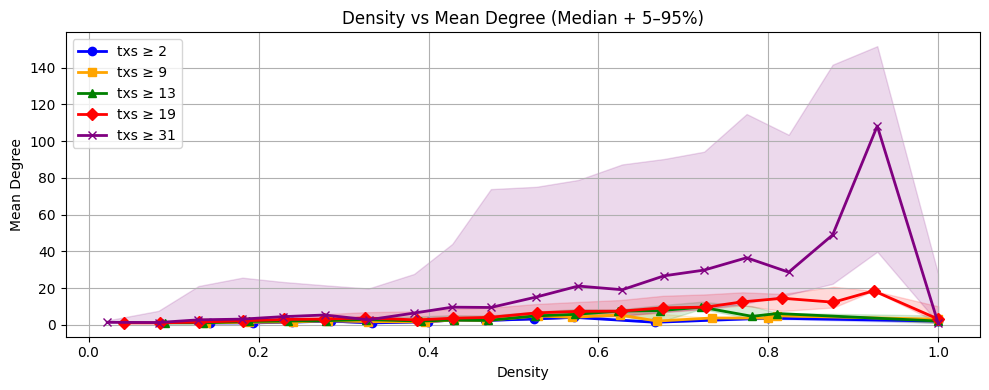

In [60]:
# mean degree vs density
plt.figure(figsize=(10, 4))

for i, (low, high) in enumerate(ranges):

    group = df_merge_deg[
        (df_merge_deg["block_size"] > low) &
        (df_merge_deg["block_size"] <= high)
    ]
    if group.empty:
        continue

    stats = group.groupby("density_bin")["mean_degree"].agg(
        median="median",
        p5=lambda x: np.percentile(x, 5) if len(x) else np.nan,
        p95=lambda x: np.percentile(x, 95) if len(x) else np.nan,
    )

    centers = group.groupby("density_bin")["density"].mean()

    stats = stats.reindex(centers.index)
    mask = ~stats["median"].isna()
    stats = stats[mask]
    centers = centers[mask]

    plt.fill_between(
        centers,
        stats["p5"],
        stats["p95"],
        alpha=0.15,
        color=colors[i],
    )

    plt.plot(
        centers,
        stats["median"],
        marker=markers[i],
        color=colors[i],
        linewidth=2,
        label=labels[i],
    )

plt.xlabel("Density")
plt.ylabel("Mean Degree")
plt.title("Density vs Mean Degree (Median + 5–95%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# mean degree is similar to max degree due to graphs mostly being clique


Assortativity (measure of similarity) (in terms of node's degree)

In [61]:
assortativity = {}

for cp, G in graphs.items():
    # Skip empty or trivial graphs
    if G.number_of_nodes() < 2:
        assortativity[cp] = 0
        continue

    # DEGREE ASSORTATIVITY
    try:
        assortativity[cp] = nx.degree_assortativity_coefficient(G)
    except:
        assortativity[cp] = 0

c:\Users\Haygen Tsoi\.conda\envs\research_project\Lib\site-packages\networkx\algorithms\assortativity\correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return float((xy * (M - ab)).sum() / np.sqrt(vara * varb))


C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\437784235.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = group.groupby("density_bin")["assort"].agg(
C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\437784235.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = group.groupby("density_bin")["density"].mean()


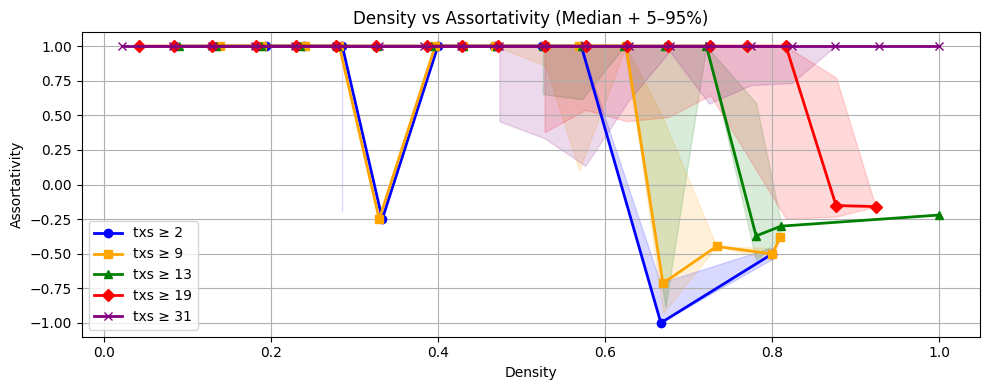

In [62]:
df_assort = pd.DataFrame(list(assortativity.items()), columns=["checkpoint", "assort"])

# Merge density + assortativity + block size
df_merge_ast = (
    df_density
    .merge(df_assort, on="checkpoint", how="inner")
    .merge(df_sizes.rename(columns={"size": "block_size"}), on="checkpoint", how="inner")
)

q25, q50, q75, q90 = np.percentile(df_merge_ast["block_size"], [25, 50, 75, 90])

ranges = [
    (0, q25),
    (q25, q50),
    (q50, q75),
    (q75, q90),
    (q90, np.inf),
]

mins = [
    df_merge["block_size"].min(),
    q25,
    q50,
    q75,
    q90
]

labels = [f"txs ≥ {m:.0f}" for m in mins]

colors = ["blue", "orange", "green", "red", "purple"]
markers = ["o", "s", "^", "D", "x"]

df_merge_ast["density_bin"] = pd.cut(df_merge_ast["density"], bins=20)

plt.figure(figsize=(10, 4))

for i, (low, high) in enumerate(ranges):

    group = df_merge_ast[
        (df_merge_ast["block_size"] > low) &
        (df_merge_ast["block_size"] <= high)
    ]
    if group.empty:
        continue

    stats = group.groupby("density_bin")["assort"].agg(
        median="median",
        p5=lambda x: np.percentile(x, 5) if len(x) else np.nan,
        p95=lambda x: np.percentile(x, 95) if len(x) else np.nan,
    )

    centers = group.groupby("density_bin")["density"].mean()

    stats = stats.reindex(centers.index)
    mask = ~stats["median"].isna()
    stats = stats[mask]
    centers = centers[mask]

    # Fill 5–95% band
    plt.fill_between(
        centers,
        stats["p5"],
        stats["p95"],
        alpha=0.15,
        color=colors[i],
    )

    # Plot median line
    plt.plot(
        centers,
        stats["median"],
        marker=markers[i],
        color=colors[i],
        linewidth=2,
        label=labels[i],
    )

plt.xlabel("Density")
plt.ylabel("Assortativity")
plt.title("Density vs Assortativity (Median + 5–95%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Results show most assortativity being 1 suggesting most graphs are clique
# Negative assortativity in low transaction graphs at high density showing star like structures and central hubs

Chromatic number (Greedy) (Parallelisam upper bound)

In [63]:
chromatic_number = {}

for cp, G in graphs.items():
    # Skip empty or trivial graphs
    if G.number_of_nodes() < 2:
        chromatic_number[cp] = 1 if G.number_of_nodes() == 1 else 0
        continue

    # CHROMATIC NUMBER (GREEDY APPROXIMATION)
    coloring = greedy_color(G, strategy="largest_first") 
    chromatic_number[cp] = len(set(coloring.values()))

C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\966019536.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = group.groupby("density_bin")["chromatic"].agg(
C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\966019536.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = group.groupby("density_bin")["density"].mean()


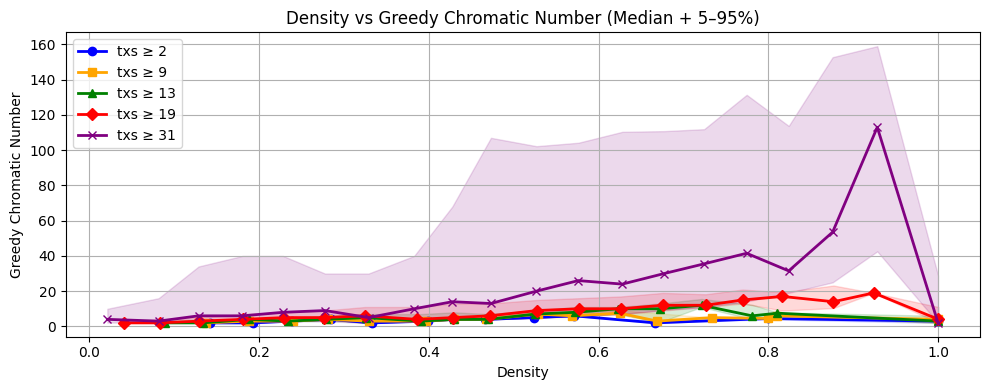

In [64]:
df_chroma = pd.DataFrame(list(chromatic_number.items()), 
                         columns=["checkpoint", "chromatic"])

df_merge_chroma = (
    df_density
    .merge(df_chroma, on="checkpoint", how="inner")
    .merge(df_sizes.rename(columns={"size": "block_size"}), on="checkpoint", how="inner")
)

q25, q50, q75, q90 = np.percentile(df_merge_chroma["block_size"], [25, 50, 75, 90])

ranges = [
    (0, q25),
    (q25, q50),
    (q50, q75),
    (q75, q90),
    (q90, np.inf),
]

mins = [
    df_merge["block_size"].min(),
    q25,
    q50,
    q75,
    q90
]

labels = [f"txs ≥ {m:.0f}" for m in mins]

colors = ["blue", "orange", "green", "red", "purple"]
markers = ["o", "s", "^", "D", "x"]

df_merge_chroma["density_bin"] = pd.cut(df_merge_chroma["density"], bins=20)

plt.figure(figsize=(10, 4))

for i, (low, high) in enumerate(ranges):

    group = df_merge_chroma[
        (df_merge_chroma["block_size"] > low) &
        (df_merge_chroma["block_size"] <= high)
    ]
    if group.empty:
        continue

    stats = group.groupby("density_bin")["chromatic"].agg(
        median="median",
        p5=lambda x: np.percentile(x, 5) if len(x) else np.nan,
        p95=lambda x: np.percentile(x, 95) if len(x) else np.nan,
    )

    centers = group.groupby("density_bin")["density"].mean()

    stats = stats.reindex(centers.index)
    mask = ~stats["median"].isna()
    stats = stats[mask]
    centers = centers[mask]

    # 5–95% band
    plt.fill_between(
        centers,
        stats["p5"],
        stats["p95"],
        alpha=0.15,
        color=colors[i],
    )

    # Median curve
    plt.plot(
        centers,
        stats["median"],
        marker=markers[i],
        color=colors[i],
        linewidth=2,
        label=labels[i],
    )

plt.xlabel("Density")
plt.ylabel("Greedy Chromatic Number")
plt.title("Density vs Greedy Chromatic Number (Median + 5–95%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Clique Number (Parallelism Lower Bound) (Using approximation algorithm)

In [65]:
clique_sizes = {}

for cp, G in graphs.items():
    if G.number_of_nodes() == 0:
        clique_sizes[cp] = 0
        continue

    # Fast greedy heuristic for max clique size
    clique_sizes[cp] = large_clique_size(G)


C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\1471712354.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = group.groupby("density_bin")["clique_size"].agg(
C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\1471712354.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = group.groupby("density_bin")["density"].mean()


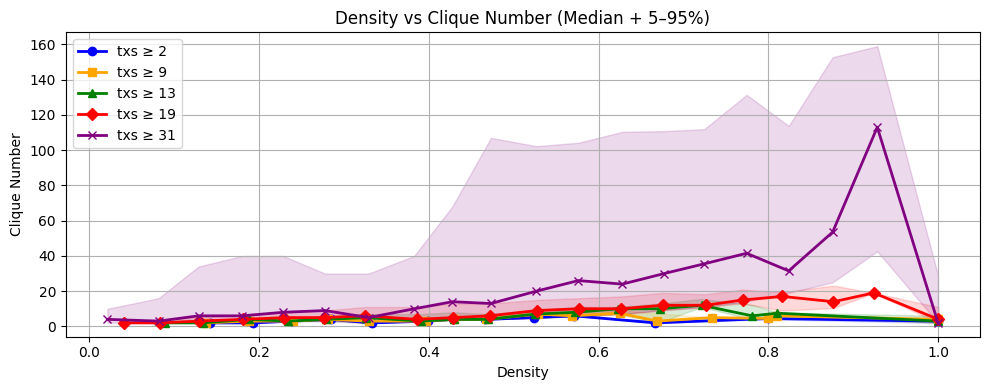

In [66]:
df_clique = pd.DataFrame(list(clique_sizes.items()), columns=["checkpoint", "clique_size"])

df_merge_clique = (
    df_density
    .merge(df_clique, on="checkpoint", how="inner")
    .merge(df_sizes.rename(columns={"size": "block_size"}), on="checkpoint", how="inner")
)

q25, q50, q75, q90 = np.percentile(df_merge_clique["block_size"], 
                                   [25, 50, 75, 90])

ranges = [
    (0, q25),
    (q25, q50),
    (q50, q75),
    (q75, q90),
    (q90, np.inf),
]

mins = [
    df_merge["block_size"].min(),
    q25,
    q50,
    q75,
    q90
]

labels = [f"txs ≥ {m:.0f}" for m in mins]

colors = ["blue", "orange", "green", "red", "purple"]
markers = ["o", "s", "^", "D", "x"]

df_merge_clique["density_bin"] = pd.cut(df_merge_clique["density"], bins=20)

plt.figure(figsize=(10, 4))

for i, (low, high) in enumerate(ranges):

    group = df_merge_clique[
        (df_merge_clique["block_size"] > low) &
        (df_merge_clique["block_size"] <= high)
    ]
    if group.empty:
        continue

    stats = group.groupby("density_bin")["clique_size"].agg(
        median="median",
        p5=lambda x: np.percentile(x, 5) if len(x) else np.nan,
        p95=lambda x: np.percentile(x, 95) if len(x) else np.nan,
    )

    centers = group.groupby("density_bin")["density"].mean()

    stats = stats.reindex(centers.index)
    mask = ~stats["median"].isna()
    stats = stats[mask]
    centers = centers[mask]

    # 5–95% band
    plt.fill_between(
        centers,
        stats["p5"],
        stats["p95"],
        alpha=0.15,
        color=colors[i],
    )

    # median curve
    plt.plot(
        centers,
        stats["median"],
        marker=markers[i],
        color=colors[i],
        linewidth=2,
        label=labels[i],
    )

plt.xlabel("Density")
plt.ylabel("Clique Number")
plt.title("Density vs Clique Number (Median + 5–95%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Largest connected component (Parallelism upper bound)

In [67]:
largest_cc = {}

for cp, G in graphs.items():
    if G.number_of_nodes() == 0:
        continue
    largest_cc[cp] = len(max(nx.connected_components(G), key=len))

C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\3779557806.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = group.groupby("density_bin")["largest_cc"].agg(
C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\3779557806.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = group.groupby("density_bin")["density"].mean()


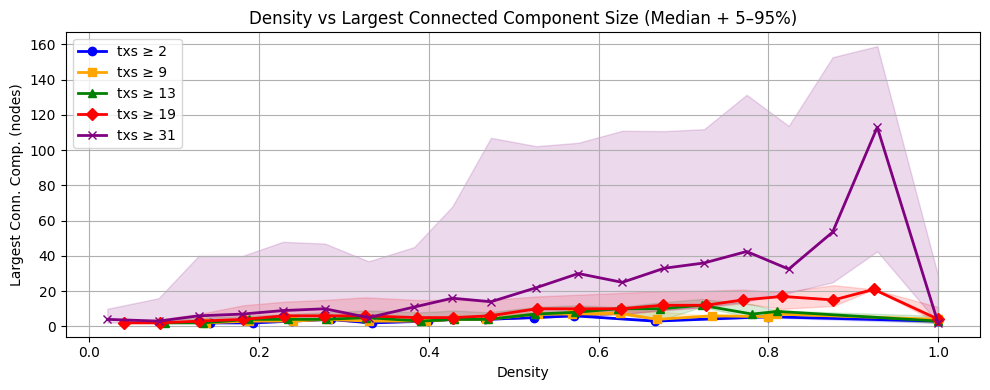

In [68]:
df_lcc = pd.DataFrame(list(largest_cc.items()), 
                      columns=["checkpoint", "largest_cc"])

# Merge density + largest_cc + block size
df_merge_lcc = (
    df_density
    .merge(df_lcc, on="checkpoint", how="inner")
    .merge(df_sizes.rename(columns={"size": "block_size"}), 
           on="checkpoint", how="inner")
)

q25, q50, q75, q90 = np.percentile(df_merge_lcc["block_size"], 
                                   [25, 50, 75, 90])

ranges = [
    (0, q25),
    (q25, q50),
    (q50, q75),
    (q75, q90),
    (q90, np.inf),
]

mins = [
    df_merge["block_size"].min(),
    q25,
    q50,
    q75,
    q90
]

labels = [f"txs ≥ {m:.0f}" for m in mins]

colors = ["blue", "orange", "green", "red", "purple"]
markers = ["o", "s", "^", "D", "x"]

df_merge_lcc["density_bin"] = pd.cut(df_merge_lcc["density"], bins=20)

plt.figure(figsize=(10, 4))

for i, (low, high) in enumerate(ranges):

    group = df_merge_lcc[
        (df_merge_lcc["block_size"] > low) &
        (df_merge_lcc["block_size"] <= high)
    ]
    if group.empty:
        continue

    stats = group.groupby("density_bin")["largest_cc"].agg(
        median="median",
        p5=lambda x: np.percentile(x, 5) if len(x) else np.nan,
        p95=lambda x: np.percentile(x, 95) if len(x) else np.nan,
    )

    centers = group.groupby("density_bin")["density"].mean()

    # Align indexes
    stats = stats.reindex(centers.index)
    mask = ~stats["median"].isna()
    stats = stats[mask]
    centers = centers[mask]

    # 5–95% band
    plt.fill_between(
        centers,
        stats["p5"],
        stats["p95"],
        alpha=0.15,
        color=colors[i],
    )

    # Median curve
    plt.plot(
        centers,
        stats["median"],
        marker=markers[i],
        color=colors[i],
        linewidth=2,
        label=labels[i],
    )

plt.xlabel("Density")
plt.ylabel("Largest Conn. Comp. (nodes)")
plt.title("Density vs Largest Connected Component Size (Median + 5–95%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Longest simple path (Parallelism lower bound)

In [69]:
# skip this graph since it's the same as diameter
longest_simple_path = {}

for cp, G in graphs.items():
    if G.number_of_nodes() < 2:
        longest_simple_path[cp] = 0
        continue

    max_diameter = 0

    # Process each connected component separately
    for component_nodes in nx.connected_components(G):
        C = G.subgraph(component_nodes)

        if C.number_of_nodes() < 2:
            continue

        # Eccentricity is safe here because C is connected
        ecc = nx.eccentricity(C)
        diameter = max(ecc.values())

        if diameter > max_diameter:
            max_diameter = diameter

    longest_simple_path[cp] = max_diameter


C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\1493361412.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = group.groupby("density_bin")["longest_path"].agg(
C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\1493361412.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = group.groupby("density_bin")["density"].mean()


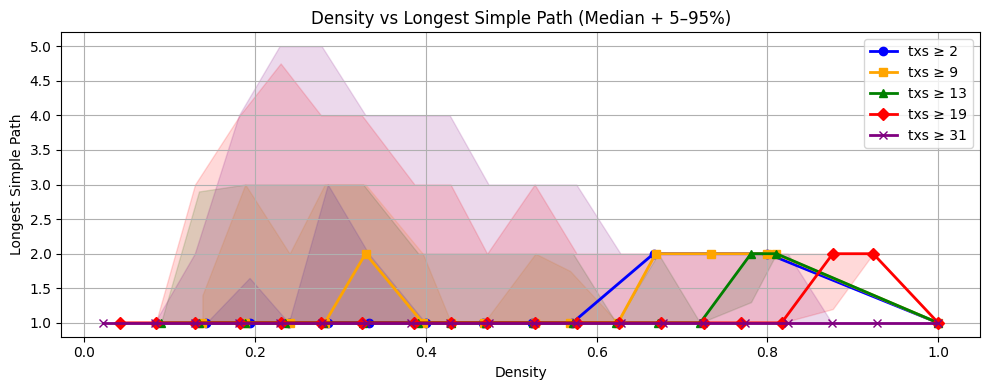

In [70]:
df_path = pd.DataFrame(list(longest_simple_path.items()), 
                       columns=["checkpoint", "longest_path"])

# Merge density + longest_path + block size
df_merge_path = (
    df_density
    .merge(df_path, on="checkpoint", how="inner")
    .merge(df_sizes.rename(columns={"size": "block_size"}), 
           on="checkpoint", how="inner")
)

q25, q50, q75, q90 = np.percentile(df_merge_path["block_size"], 
                                   [25, 50, 75, 90])

ranges = [
    (0, q25),
    (q25, q50),
    (q50, q75),
    (q75, q90),
    (q90, np.inf),
]

mins = [
    df_merge["block_size"].min(),
    q25,
    q50,
    q75,
    q90
]

labels = [f"txs ≥ {m:.0f}" for m in mins]

colors = ["blue", "orange", "green", "red", "purple"]
markers = ["o", "s", "^", "D", "x"]

df_merge_path["density_bin"] = pd.cut(df_merge_path["density"], bins=20)

plt.figure(figsize=(10, 4))

for i, (low, high) in enumerate(ranges):

    group = df_merge_path[
        (df_merge_path["block_size"] > low) &
        (df_merge_path["block_size"] <= high)
    ]
    if group.empty:
        continue

    stats = group.groupby("density_bin")["longest_path"].agg(
        median="median",
        p5=lambda x: np.percentile(x, 5) if len(x) else np.nan,
        p95=lambda x: np.percentile(x, 95) if len(x) else np.nan,
    )

    centers = group.groupby("density_bin")["density"].mean()

    stats = stats.reindex(centers.index)
    mask = ~stats["median"].isna()
    stats = stats[mask]
    centers = centers[mask]

    # 5–95% band
    plt.fill_between(
        centers,
        stats["p5"],
        stats["p95"],
        alpha=0.15,
        color=colors[i],
    )

    # Median curve
    plt.plot(
        centers,
        stats["median"],
        marker=markers[i],
        color=colors[i],
        linewidth=2,
        label=labels[i],
    )

plt.xlabel("Density")
plt.ylabel("Longest Simple Path")
plt.title("Density vs Longest Simple Path (Median + 5–95%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Longest simple path to chromatic number ratio

Lower bound (Divide longest simple path (diameter in our case) by greedy colouring number)

In [71]:
# Merge: density + longest_path + chromatic + block size
df_ratio = (
    df_density
    .merge(df_path, on="checkpoint", how="inner")
    .merge(df_chroma, on="checkpoint", how="inner")
    .merge(df_sizes.rename(columns={"size": "block_size"}), on="checkpoint", how="inner")
)

# Compute lower bound: longest_simple_path / greedy chromatic number
# Avoid division by zero; drop trivial graphs (<2 nodes) via NaN
df_ratio["ratio"] = np.where(
    df_ratio["chromatic"] > 0,
    df_ratio["longest_path"] / df_ratio["chromatic"],
    np.nan
)


C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\424719922.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = group.groupby("density_bin")["ratio"].agg(
C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\424719922.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = group.groupby("density_bin")["density"].mean()


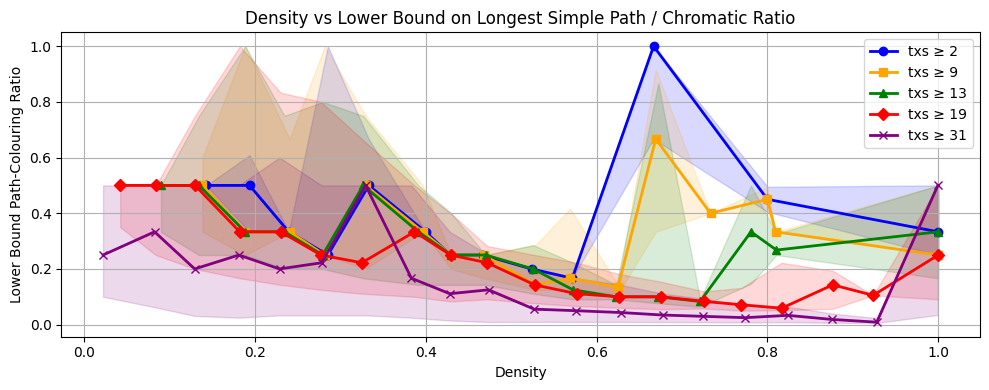

In [72]:
# Block-size quantiles
q25, q50, q75, q90 = np.percentile(df_ratio["block_size"],
                                   [25, 50, 75, 90])

ranges = [
    (0, q25),
    (q25, q50),
    (q50, q75),
    (q75, q90),
    (q90, np.inf),
]

mins = [
    df_merge["block_size"].min(),
    q25,
    q50,
    q75,
    q90
]

labels = [f"txs ≥ {m:.0f}" for m in mins]

colors  = ["blue", "orange", "green", "red", "purple"]
markers = ["o", "s", "^", "D", "x"]

# Density bins
df_ratio["density_bin"] = pd.cut(df_ratio["density"], bins=20)

plt.figure(figsize=(10, 4))

for i, (low, high) in enumerate(ranges):

    group = df_ratio[
        (df_ratio["block_size"] > low) &
        (df_ratio["block_size"] <= high)
    ]
    if group.empty:
        continue

    # Aggregate within density-bin
    stats = group.groupby("density_bin")["ratio"].agg(
        median="median",
        p5=lambda x: np.percentile(x, 5) if len(x) else np.nan,
        p95=lambda x: np.percentile(x, 95) if len(x) else np.nan,
    )

    centers = group.groupby("density_bin")["density"].mean()

    # Align + drop NaNs
    stats = stats.reindex(centers.index)
    mask = ~stats["median"].isna()
    stats   = stats[mask]
    centers = centers[mask]

    # 5–95% band
    plt.fill_between(
        centers,
        stats["p5"],
        stats["p95"],
        alpha=0.15,
        color=colors[i],
    )

    # Median curve
    plt.plot(
        centers,
        stats["median"],
        marker=markers[i],
        color=colors[i],
        linewidth=2,
        label=labels[i],
    )

plt.xlabel("Density")
plt.ylabel("Lower Bound Path-Colouring Ratio")
plt.title("Density vs Lower Bound on Longest Simple Path / Chromatic Ratio")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Lower bound show dependency chains. Low values - suggesting cliques and short dependency chains

Upper bound (Divide the size of largest connected component by the clique number)

In [73]:
# Merge density + largest_cc + clique number + block size
df_upper = (
    df_density
    .merge(df_lcc, on="checkpoint", how="inner")
    .merge(df_clique, on="checkpoint", how="inner")
    .merge(df_sizes.rename(columns={"size": "block_size"}), on="checkpoint", how="inner")
)

# Compute upper bound = largest CC / clique number
df_upper["upper_ratio"] = np.where(
    df_upper["clique_size"] > 0,
    df_upper["largest_cc"] / df_upper["clique_size"],
    np.nan
)

C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\961677979.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = group.groupby("density_bin")["upper_ratio"].agg(
C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_4184\961677979.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = group.groupby("density_bin")["density"].mean()


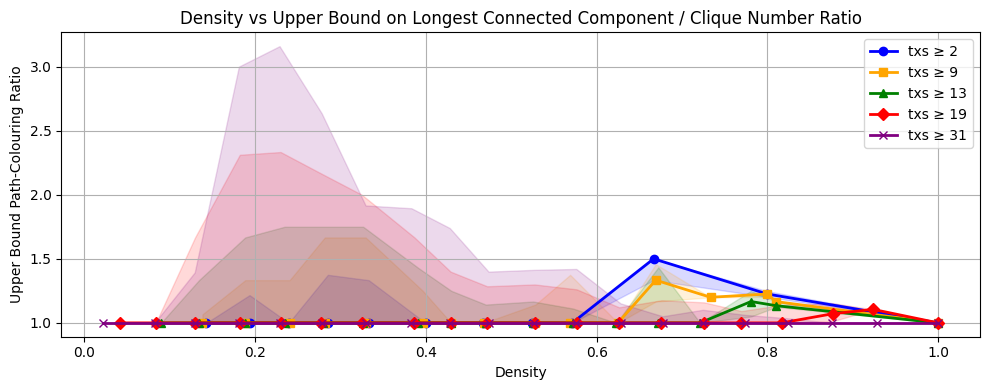

In [74]:
q25, q50, q75, q90 = np.percentile(df_upper["block_size"], 
                                   [25, 50, 75, 90])

ranges = [
    (0, q25),
    (q25, q50),
    (q50, q75),
    (q75, q90),
    (q90, np.inf),
]

mins = [
    df_merge["block_size"].min(),
    q25,
    q50,
    q75,
    q90
]

labels = [f"txs ≥ {m:.0f}" for m in mins]

colors  = ["blue", "orange", "green", "red", "purple"]
markers = ["o", "s", "^", "D", "x"]

df_upper["density_bin"] = pd.cut(df_upper["density"], bins=20)

plt.figure(figsize=(10, 4))

for i, (low, high) in enumerate(ranges):

    group = df_upper[
        (df_upper["block_size"] > low) &
        (df_upper["block_size"] <= high)
    ]
    if group.empty:
        continue

    stats = group.groupby("density_bin")["upper_ratio"].agg(
        median="median",
        p5=lambda x: np.percentile(x, 5) if len(x) else np.nan,
        p95=lambda x: np.percentile(x, 95) if len(x) else np.nan,
    )

    centers = group.groupby("density_bin")["density"].mean()

    stats = stats.reindex(centers.index)
    mask = ~stats["median"].isna()
    stats   = stats[mask]
    centers = centers[mask]

    # 5–95% band
    plt.fill_between(
        centers,
        stats["p5"],
        stats["p95"],
        alpha=0.15,
        color=colors[i],
    )

    # Median curve
    plt.plot(
        centers,
        stats["median"],
        marker=markers[i],
        color=colors[i],
        linewidth=2,
        label=labels[i],
    )

plt.xlabel("Density")
plt.ylabel("Upper Bound Path-Colouring Ratio")
plt.title("Density vs Upper Bound on Longest Connected Component / Clique Number Ratio")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Upper bound shows potential parallelism inside conflict set
# Result shows parallelism can be done for low number of transactions in high density sets


Historical development of the number of transactiosn per checkpoint on Sui mainnet and the gas price

In [75]:
cur.execute("""
    SELECT
        timestamp,
        user_tx_count,
        system_tx_count
    FROM checkpoints
    ORDER BY timestamp;
""")

rows = cur.fetchall()

df_tx = pd.DataFrame(
    rows,
    columns=["timestamp", "user_tx_count", "system_tx_count"]
)

df_tx["timestamp"] = pd.to_datetime(df_tx["timestamp"], utc=True)
df_tx["tx_count"] = df_tx["user_tx_count"] + df_tx["system_tx_count"]


In [76]:
cur.execute("""
    SELECT
        c.timestamp,
        AVG(t.gas_price) AS avg_gas_price
    FROM transactions t
    JOIN checkpoints c
        ON t.checkpoint_sequence = c.sequence_number
    GROUP BY c.timestamp
    ORDER BY c.timestamp;
""")

rows = cur.fetchall()

df_price = pd.DataFrame(
    rows,
    columns=["timestamp", "avg_gas_price"]
)

df_price["timestamp"] = pd.to_datetime(df_price["timestamp"], utc=True)
df_price["avg_gas_price"] = pd.to_numeric(df_price["avg_gas_price"], errors="coerce")


In [77]:
df_cp = (
    df_tx[["timestamp", "tx_count"]]
    .merge(df_price, on="timestamp", how="inner")
)

In [78]:
df_tx_price_daily = (
    df_cp
    .assign(day=df_cp["timestamp"].dt.date)
    .groupby("day")
    .agg(
        tx_mean=("tx_count", "mean"),
        tx_std=("tx_count", "std"),
        tx_n=("tx_count", "count"),
        price_mean=("avg_gas_price", "mean"),
        price_std=("avg_gas_price", "std"),
        price_n=("avg_gas_price", "count"),
    )
    .reset_index()
)

# 95% CI
df_tx_price_daily["tx_ci95"] = (
    1.96 * df_tx_price_daily["tx_std"] / np.sqrt(df_tx_price_daily["tx_n"])
)
df_tx_price_daily["price_ci95"] = (
    1.96 * df_tx_price_daily["price_std"] / np.sqrt(df_tx_price_daily["price_n"])
)

df_tx_price_daily["day"] = pd.to_datetime(df_tx_price_daily["day"])

# numeric safety
cols = ["tx_mean", "tx_ci95", "price_mean", "price_ci95"]
df_tx_price_daily[cols] = df_tx_price_daily[cols].astype(float)


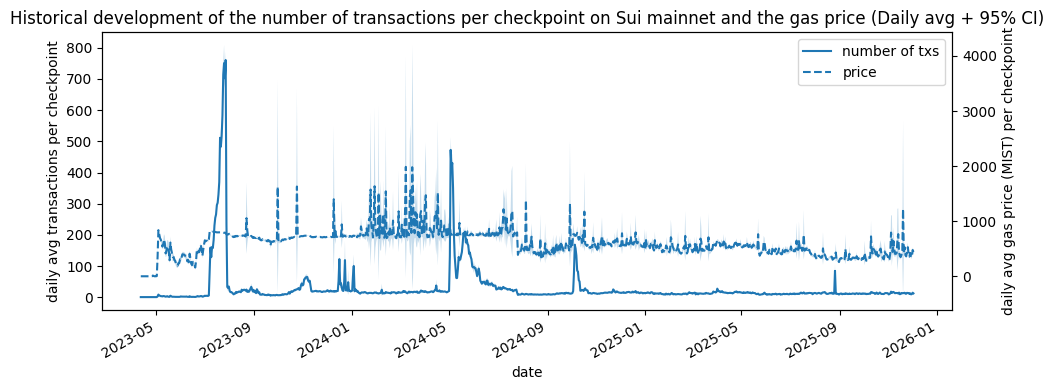

In [79]:
fig, ax1 = plt.subplots(figsize=(10, 4))

# tx count
ax1.plot(
    df_tx_price_daily["day"],
    df_tx_price_daily["tx_mean"],
    label="number of txs"
)
ax1.fill_between(
    df_tx_price_daily["day"],
    df_tx_price_daily["tx_mean"] - df_tx_price_daily["tx_ci95"],
    df_tx_price_daily["tx_mean"] + df_tx_price_daily["tx_ci95"],
    alpha=0.25
)
ax1.set_ylabel("daily avg transactions per checkpoint")
ax1.set_xlabel("date")

# gas price
ax2 = ax1.twinx()
ax2.plot(
    df_tx_price_daily["day"],
    df_tx_price_daily["price_mean"],
    linestyle="--",
    label="price"
)
ax2.fill_between(
    df_tx_price_daily["day"],
    df_tx_price_daily["price_mean"] - df_tx_price_daily["price_ci95"],
    df_tx_price_daily["price_mean"] + df_tx_price_daily["price_ci95"],
    alpha=0.25
)
ax2.set_ylabel("daily avg gas price (MIST) per checkpoint")

ax1.set_title(
    "Historical development of the number of transactions per checkpoint on Sui mainnet "
    "and the gas price (Daily avg + 95% CI)"
)

ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.show()


Historical development of the number of concurrent write access per checkpoint

In [80]:
# graphs: dict[checkpoint] -> nx.Graph
# each graph has nodes = txs with ≥1 concurrent write edge

# 1) build per-checkpoint counts
df_cw = pd.DataFrame(
    [(int(cp), G.number_of_nodes()) for cp, G in graphs.items()],
    columns=["checkpoint", "cw_tx_count"]
)

# 2) fetch timestamps for those checkpoints
checkpoints = df_cw["checkpoint"].tolist()

rows = []
chunk = 5000
for i in range(0, len(checkpoints), chunk):
    cps = checkpoints[i:i+chunk]
    placeholders = ",".join(["%s"] * len(cps))
    cur.execute(
        f"""
        SELECT sequence_number, timestamp
        FROM checkpoints
        WHERE sequence_number IN ({placeholders})
        """,
        cps
    )
    rows.extend(cur.fetchall())

df_ts = pd.DataFrame(rows, columns=["checkpoint", "timestamp"])
df_ts["checkpoint"] = df_ts["checkpoint"].astype(int)
df_ts["timestamp"] = pd.to_datetime(df_ts["timestamp"], utc=True)

# 3) merge
df_plot = (
    df_cw
    .merge(df_ts, on="checkpoint", how="inner")
)

# 4) daily aggregation + 95% CI
df_cw_daily = (
    df_plot
    .assign(day=df_plot["timestamp"].dt.date)
    .groupby("day")["cw_tx_count"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

df_cw_daily["cw_ci95"] = (
    1.96 * df_cw_daily["std"] / np.sqrt(df_cw_daily["count"])
)

df_cw_daily["day"] = pd.to_datetime(df_cw_daily["day"])
df_cw_daily = df_cw_daily.rename(columns={"mean": "cw_mean"})

# ensure numeric + clean
df_cw_daily[["cw_mean", "cw_ci95"]] = df_cw_daily[["cw_mean", "cw_ci95"]].astype(float)
df_cw_daily = df_cw_daily.dropna(subset=["cw_mean", "cw_ci95"])


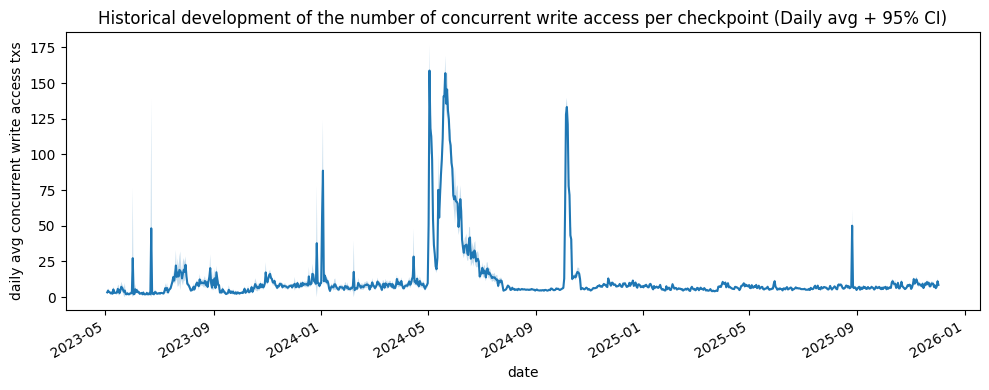

In [81]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    df_cw_daily["day"],
    df_cw_daily["cw_mean"]
)
ax.fill_between(
    df_cw_daily["day"],
    (df_cw_daily["cw_mean"] - df_cw_daily["cw_ci95"]).clip(lower=0),
    df_cw_daily["cw_mean"] + df_cw_daily["cw_ci95"],
    alpha=0.25
)

ax.set_ylabel("daily avg concurrent write access txs")
ax.set_xlabel("date")
ax.set_title(
    "Historical development of the number of concurrent write access per checkpoint "
    "(Daily avg + 95% CI)"
)

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()


Daily average of gas used

In [82]:
cur.execute("""
    SELECT
        t.checkpoint_sequence AS checkpoint,
        t.gas_used,
        c.timestamp
    FROM transactions t
    JOIN checkpoints c
        ON t.checkpoint_sequence = c.sequence_number
""")

rows = cur.fetchall()

df_tx_gas = pd.DataFrame(
    rows,
    columns=["checkpoint", "gas_used", "timestamp"]
)

df_tx_gas["checkpoint"] = df_tx_gas["checkpoint"].astype(int)
df_tx_gas["gas_used"] = pd.to_numeric(df_tx_gas["gas_used"], errors="coerce")
df_tx_gas["timestamp"] = pd.to_datetime(df_tx_gas["timestamp"], utc=True)

# ---------- build df_block from df_tx ----------

df_block = (
    df_tx_gas
    .groupby("checkpoint")
    .agg(
        block_gas=("gas_used", "sum"),
        max_tx_gas=("gas_used", "max"),
        timestamp=("timestamp", "first"),
    )
    .reset_index()
)

In [83]:
# ---------- 1) prepare basics ----------

df_block["checkpoint"] = df_block["checkpoint"].astype(int)
df_block["timestamp"] = pd.to_datetime(df_block["timestamp"], utc=True)

df_lcc["checkpoint"] = df_lcc["checkpoint"].astype(int)
df_clique["checkpoint"] = df_clique["checkpoint"].astype(int)

df_tx_gas["checkpoint"] = df_tx_gas["checkpoint"].astype(int)
df_tx_gas["gas_used"] = pd.to_numeric(df_tx_gas["gas_used"], errors="coerce")

# tx count per checkpoint
df_tx_count = (
    df_tx_gas
    .groupby("checkpoint")
    .size()
    .rename("tx_count")
    .reset_index()
)

# ---------- 2) merge everything ----------

df = (
    df_block
    .merge(df_lcc, on="checkpoint", how="inner")
    .merge(df_clique, on="checkpoint", how="inner")
    .merge(df_tx_count, on="checkpoint", how="inner")
)

# ---------- 3) approximate CC / clique gas ----------

df["avg_tx_gas"] = df["block_gas"] / df["tx_count"]
df["cc_gas"] = df["largest_cc"] * df["avg_tx_gas"]
df["clique_gas"] = df["clique_size"] * df["avg_tx_gas"]

# ---------- 4) daily aggregation + 95% CI ----------

metrics = {
    "block_gas": "block_gas",
    "cc_gas": "cc_gas",
    "clique_gas": "clique_gas",
    "max_tx_gas": "max_tx_gas",
}

df_gas_daily = (
    df
    .assign(day=df["timestamp"].dt.date)
    .groupby("day")[list(metrics.values())]
    .agg(["mean", "std", "count"])
)

# flatten columns
df_gas_daily.columns = ["_".join(c) for c in df_gas_daily.columns]
df_gas_daily = df_gas_daily.reset_index()

# compute 95% CI
for m in metrics.values():
    df_gas_daily[f"{m}_ci95"] = (
        1.96 * df_gas_daily[f"{m}_std"] / np.sqrt(df_gas_daily[f"{m}_count"])
    )

df_gas_daily["day"] = pd.to_datetime(df_gas_daily["day"])

# numeric safety
cols = [c for c in df_gas_daily.columns if c != "day"]
df_gas_daily[cols] = df_gas_daily[cols].astype(float)

# optional cleanup
df_gas_daily = df_gas_daily.dropna(
    subset=[f"{m}_mean" for m in metrics.values()]
)


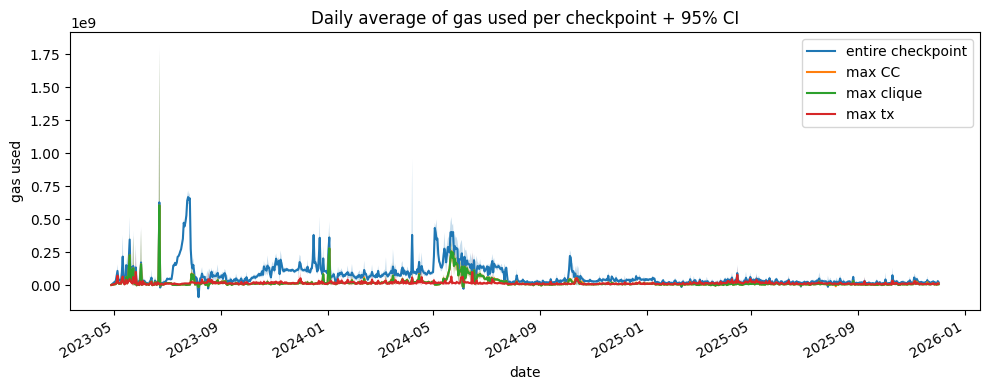

In [84]:
fig, ax = plt.subplots(figsize=(10, 4))

def plot_ci(x, mean, ci, label):
    ax.plot(x, mean, label=label)
    ax.fill_between(
        x,
        (mean - ci).clip(lower=0),
        mean + ci,
        alpha=0.25
    )

x = df_gas_daily["day"]

plot_ci(x, df_gas_daily["block_gas_mean"],  df_gas_daily["block_gas_ci95"],  "entire checkpoint")
plot_ci(x, df_gas_daily["cc_gas_mean"],     df_gas_daily["cc_gas_ci95"],     "max CC")
plot_ci(x, df_gas_daily["clique_gas_mean"], df_gas_daily["clique_gas_ci95"], "max clique")
plot_ci(x, df_gas_daily["max_tx_gas_mean"], df_gas_daily["max_tx_gas_ci95"], "max tx")

ax.set_ylabel("gas used")
ax.set_xlabel("date")
ax.set_title("Daily average of gas used per checkpoint + 95% CI")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

ax.legend()
plt.tight_layout()
plt.show()


Higest speed up factor

In [85]:
# ---------- build df_speedup_daily ----------

df_speedup_daily = pd.DataFrame()
df_speedup_daily["day"] = df_gas_daily["day"]

# lower bound: total / max CC
df_speedup_daily["speedup_lb"] = (
    df_gas_daily["block_gas_mean"] / df_gas_daily["cc_gas_mean"]
)

# upper bound: total / max clique
df_speedup_daily["speedup_ub"] = (
    df_gas_daily["block_gas_mean"] / df_gas_daily["clique_gas_mean"]
)

# ---------- 95% CI via delta method ----------

def ratio_ci(mean_a, ci_a, mean_b, ci_b):
    ratio = mean_a / mean_b
    rel_err = np.sqrt((ci_a / mean_a) ** 2 + (ci_b / mean_b) ** 2)
    return ratio * rel_err

df_speedup_daily["speedup_lb_ci95"] = ratio_ci(
    df_gas_daily["block_gas_mean"],
    df_gas_daily["block_gas_ci95"],
    df_gas_daily["cc_gas_mean"],
    df_gas_daily["cc_gas_ci95"],
)

df_speedup_daily["speedup_ub_ci95"] = ratio_ci(
    df_gas_daily["block_gas_mean"],
    df_gas_daily["block_gas_ci95"],
    df_gas_daily["clique_gas_mean"],
    df_gas_daily["clique_gas_ci95"],
)

# numeric safety
cols = ["speedup_lb", "speedup_lb_ci95", "speedup_ub", "speedup_ub_ci95"]
df_speedup_daily[cols] = df_speedup_daily[cols].astype(float)

# optional cleanup
df_speedup_daily = df_speedup_daily.replace([np.inf, -np.inf], np.nan)
df_speedup_daily = df_speedup_daily.dropna(subset=cols)


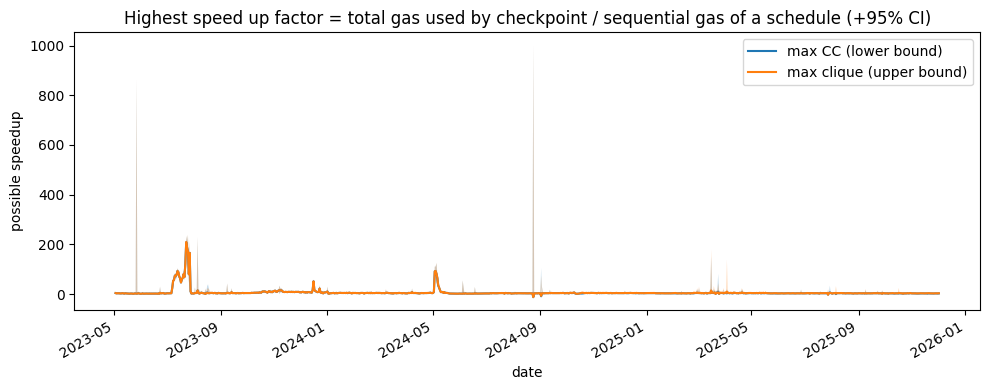

In [90]:
fig, ax = plt.subplots(figsize=(10, 4))

# lower bound (max CC)
ax.plot(
    df_speedup_daily["day"],
    df_speedup_daily["speedup_lb"],
    label="max CC (lower bound)"
)
ax.fill_between(
    df_speedup_daily["day"],
    (df_speedup_daily["speedup_lb"] - df_speedup_daily["speedup_lb_ci95"]).clip(lower=0),
    df_speedup_daily["speedup_lb"] + df_speedup_daily["speedup_lb_ci95"].clip(lower=0),
    alpha=0.25
)

# upper bound (max clique)
ax.plot(
    df_speedup_daily["day"],
    df_speedup_daily["speedup_ub"],
    label="max clique (upper bound)"
)
ax.fill_between(
    df_speedup_daily["day"],
    (df_speedup_daily["speedup_ub"] - df_speedup_daily["speedup_ub_ci95"]).clip(lower=0),
    df_speedup_daily["speedup_ub"] + df_speedup_daily["speedup_ub_ci95"].clip(lower=0),
    alpha=0.25
)

ax.set_ylabel("possible speedup")
ax.set_xlabel("date")
ax.set_title(
    "Highest speed up factor = total gas used by checkpoint / sequential gas of a schedule (+95% CI)"
)

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

ax.legend()
plt.tight_layout()
plt.show()


Concurrency Intensity, how many transactions wrote the same object in the same checkpoint. For hotspot detection, shared-object scalability analysis and parallelism limits

In [87]:
cur.execute("""SELECT
    oc.address,
    c.sequence_number AS checkpoint,
    COUNT(DISTINCT oc.transaction_digest) AS concurrent_writers
FROM object_changes oc
JOIN transactions t
    ON oc.transaction_digest = t.transaction_digest
JOIN checkpoints c
    ON t.checkpoint_sequence = c.sequence_number
GROUP BY oc.address, c.sequence_number
HAVING COUNT(DISTINCT oc.transaction_digest) > 1
ORDER BY concurrent_writers DESC;
""")

Identify smart contract hotspots

In [88]:
cur.execute("""SELECT address, COUNT(*)
FROM object_changes
WHERE change_type IN ('mutated')
GROUP BY address
ORDER BY COUNT(*) DESC
LIMIT 20;""")


Identify smart contract interaction graphs

In [89]:
cur.execute("""SELECT kind, COUNT(*)
FROM transactions
GROUP BY kind;""")
